# Student Admission Dataset Analysis

This notebook analyzes the synthetic student admission dataset generated by `generate_dataset.py`.

The dataset contains 12,000 student applications with built-in systemic biases for fairness testing.

## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
data_path = Path('../../resources/datasets/student-admission/student_admission_full.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Dataset shape: (12000, 20)

Columns: ['gender', 'race', 'socioeconomic_status', 'first_generation', 'region', 'urban_rural', 'disability_status', 'gpa', 'sat_score', 'act_score', 'ap_courses', 'honors_courses', 'class_rank_percentile', 'extracurriculars', 'leadership_positions', 'community_service_hours', 'awards_honors', 'essay_score', 'recommendation_strength', 'admitted']


## 2. Dataset Overview

In [2]:
# Basic statistics
print("Dataset Info:")
print("="*60)
df.info()

print("\n" + "="*60)
print("Numerical Features:")
print("="*60)
df.describe().round(2)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   12000 non-null  object 
 1   race                     12000 non-null  object 
 2   socioeconomic_status     12000 non-null  object 
 3   first_generation         12000 non-null  object 
 4   region                   12000 non-null  object 
 5   urban_rural              12000 non-null  object 
 6   disability_status        12000 non-null  object 
 7   gpa                      12000 non-null  float64
 8   sat_score                12000 non-null  int64  
 9   act_score                12000 non-null  int64  
 10  ap_courses               12000 non-null  int64  
 11  honors_courses           12000 non-null  int64  
 12  class_rank_percentile    12000 non-null  int64  
 13  extracurriculars         12000 non-null  int64  
 14  leadersh

,gpa,sat_score,act_score,ap_courses,honors_courses,class_rank_percentile,extracurriculars,leadership_positions,community_service_hours,awards_honors,essay_score,recommendation_strength,admitted
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,3.30,1117.03,21.40,2.80,4.93,81.30,2.55,1.00,59.83,1.62,6.25,8.50,0.30
std,0.41,184.61,5.75,2.44,3.43,13.29,1.95,1.24,42.72,1.52,1.50,1.31,0.46
min,1.52,410.00,1.00,0.00,0.00,19.00,0.00,0.00,0.00,0.00,1.00,2.90,0.00
25%,3.01,990.00,18.00,1.00,2.00,72.00,1.00,0.00,29.00,0.00,5.20,7.60,0.00
50%,3.31,1120.00,21.00,2.00,5.00,82.00,2.00,1.00,50.00,1.00,6.20,8.70,0.00
75%,3.60,1250.00,25.00,4.00,7.00,92.00,4.00,2.00,81.00,2.00,7.30,9.70,1.00
max,4.00,1600.00,36.00,12.00,15.00,100.00,10.00,5.00,350.00,8.00,10.00,10.00,1.00


In [3]:
# Overall admission rate
admission_rate = df['admitted'].mean()
print(f"Overall Admission Rate: {admission_rate:.1%}")
print(f"Admitted: {df['admitted'].sum():,}")
print(f"Rejected: {(len(df) - df['admitted'].sum()):,}")

Overall Admission Rate: 30.0%
Admitted: 3,600
Rejected: 8,400


## 3. Fairness Analysis - Admission Rates by Protected Attributes

Analyze whether admission rates differ across protected groups (indicating potential bias).

In [4]:
# Calculate admission rates by protected attributes
protected_attrs = ['gender', 'race', 'socioeconomic_status', 'first_generation', 
                   'region', 'urban_rural', 'disability_status']

print("ADMISSION RATES BY PROTECTED GROUPS")
print("="*70)

for attr in protected_attrs:
    print(f"\n{attr.upper().replace('_', ' ')}:")
    rates = df.groupby(attr)['admitted'].agg(['sum', 'count', 'mean'])
    rates.columns = ['Admitted', 'Total', 'Rate']
    rates['Rate'] = (rates['Rate'] * 100).round(1)
    rates = rates.sort_values('Rate', ascending=False)
    print(rates)
    
    # Show disparity
    disparity = rates['Rate'].max() - rates['Rate'].min()
    print(f"  → Disparity: {disparity:.1f} percentage points")

ADMISSION RATES BY PROTECTED GROUPS

GENDER:
            Admitted  Total  Rate
gender                           
Male            1785   5821  30.7
Female          1693   5732  29.5
Non-binary       122    447  27.3
  → Disparity: 3.4 percentage points

RACE:
                 Admitted  Total  Rate
race                                  
Asian                 597   1212  49.3
White                2545   6507  39.1
Other                  59    272  21.7
Black                 154   1532  10.1
Hispanic              222   2218  10.0
Native American        23    259   8.9
  → Disparity: 40.4 percentage points

SOCIOECONOMIC STATUS:
                      Admitted  Total  Rate
socioeconomic_status                       
High                      2326   3028  76.8
Middle                    1196   5157  23.2
Low                         78   3815   2.0
  → Disparity: 74.8 percentage points

FIRST GENERATION:
                  Admitted  Total  Rate
first_generation                       
No         

## 4. Visualize Admission Rates by Group

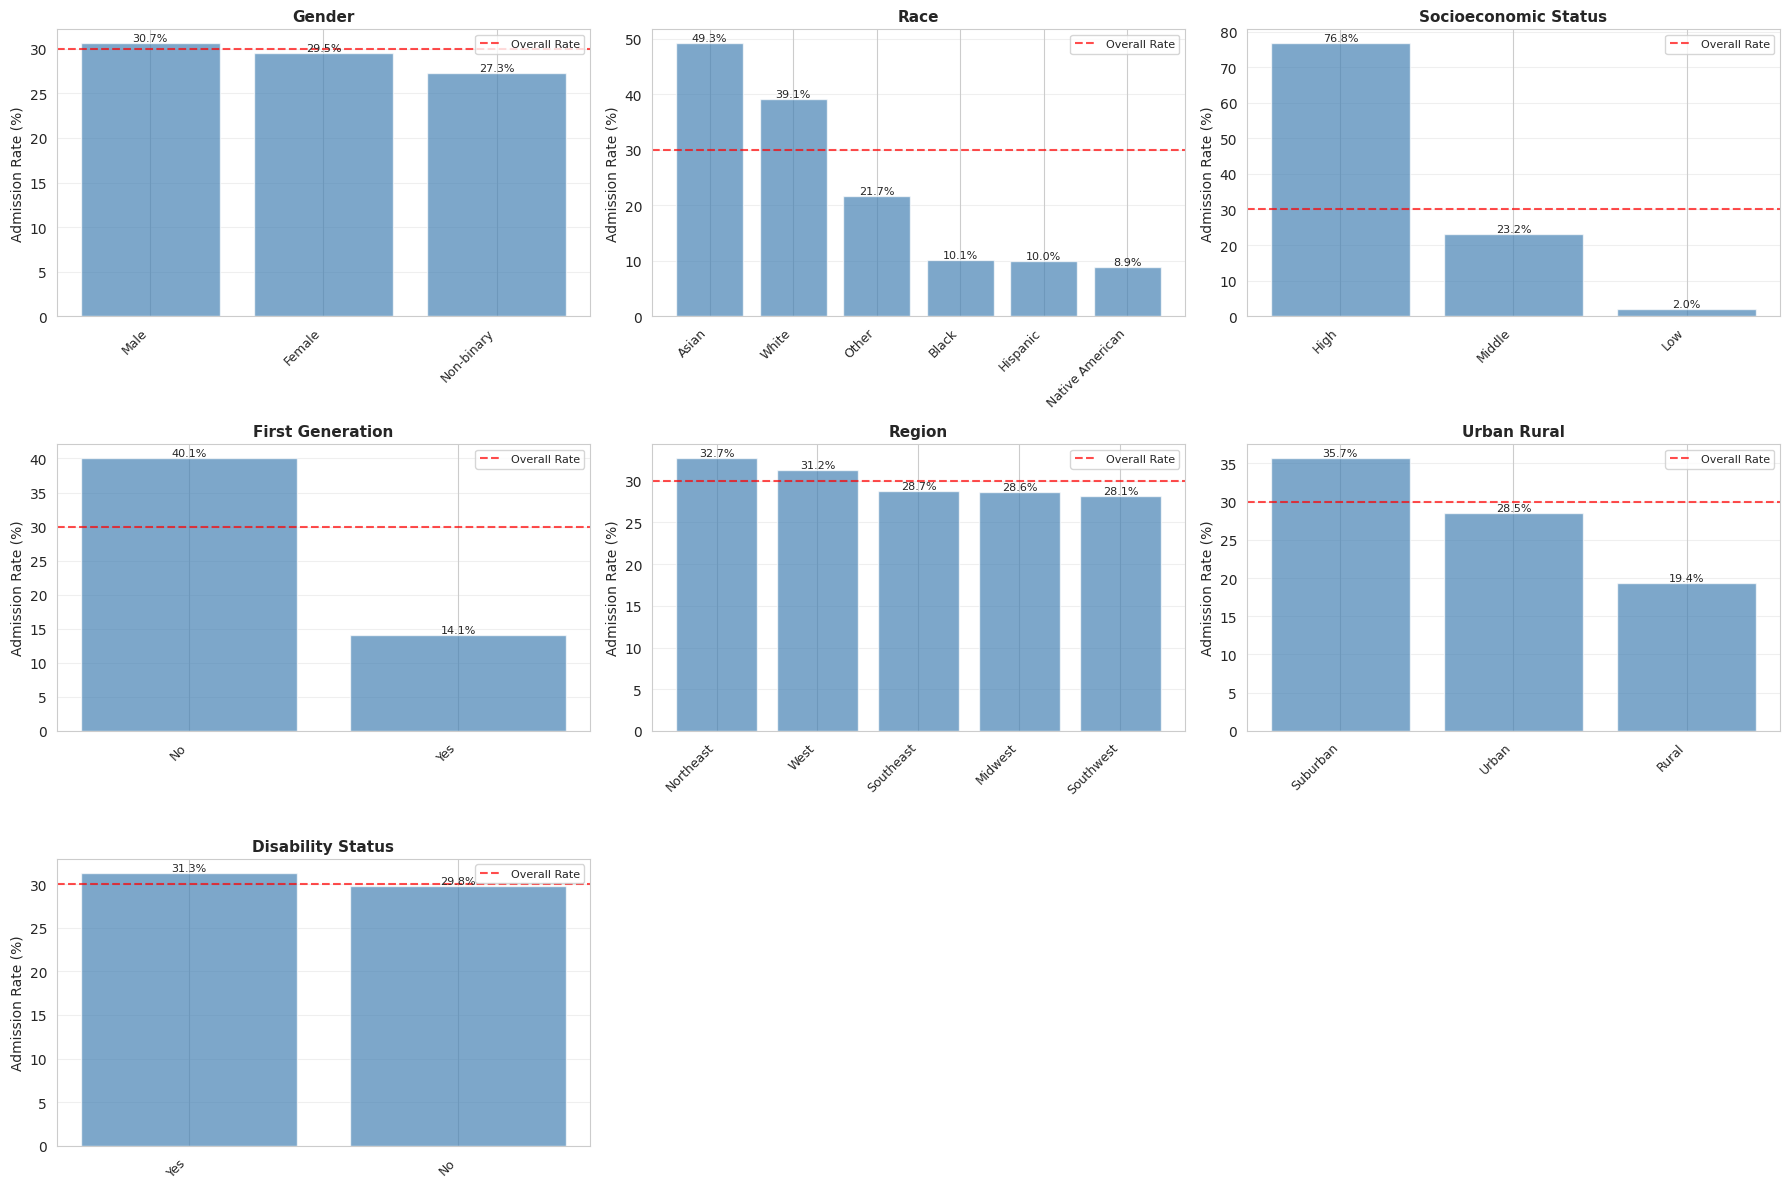

✓ Saved visualization as 'admission_rates_by_group.png'


In [5]:
# Create visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

overall_rate = df['admitted'].mean() * 100

for idx, attr in enumerate(protected_attrs):
    rates = df.groupby(attr)['admitted'].mean() * 100
    rates = rates.sort_values(ascending=False)
    
    ax = axes[idx]
    bars = ax.bar(range(len(rates)), rates.values, color='steelblue', alpha=0.7)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Admission Rate (%)', fontsize=10)
    ax.set_title(f'{attr.replace("_", " ").title()}', fontsize=11, fontweight='bold')
    ax.axhline(y=overall_rate, color='red', linestyle='--', linewidth=1.5, 
               alpha=0.7, label='Overall Rate')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Annotate bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

# Remove extra subplots
for idx in range(len(protected_attrs), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## 5. Academic Metrics by Demographics

Examine whether academic performance differs across groups (revealing systemic inequalities).

In [8]:
# Average academic metrics by race
print("AVERAGE ACADEMIC METRICS BY RACE")
print("="*70)
academic_by_race = df.groupby('race')[['gpa', 'sat_score', 'act_score', 'ap_courses']].mean().round(2)
print(academic_by_race)

print("\nAVERAGE ACADEMIC METRICS BY SOCIOECONOMIC STATUS")
print("="*70)
academic_by_ses = df.groupby('socioeconomic_status')[['gpa', 'sat_score', 'act_score', 'ap_courses']].mean().round(2)
print(academic_by_ses)

AVERAGE ACADEMIC METRICS BY RACE
                  gpa  sat_score  act_score  ap_courses
race                                                   
Asian            3.39    1212.84      24.19        3.40
Black            3.17    1044.02      19.25        2.19
Hispanic         3.18    1038.00      19.15        2.34
Native American  3.22    1017.41      18.71        2.25
Other            3.20    1069.89      19.94        2.68
White            3.36    1149.25      22.32        3.02

AVERAGE ACADEMIC METRICS BY SOCIOECONOMIC STATUS
                       gpa  sat_score  act_score  ap_courses
socioeconomic_status                                        
High                  3.48    1248.63      25.22        5.55
Low                   3.11     988.53      17.71        0.86
Middle                3.33    1134.83      21.88        2.63


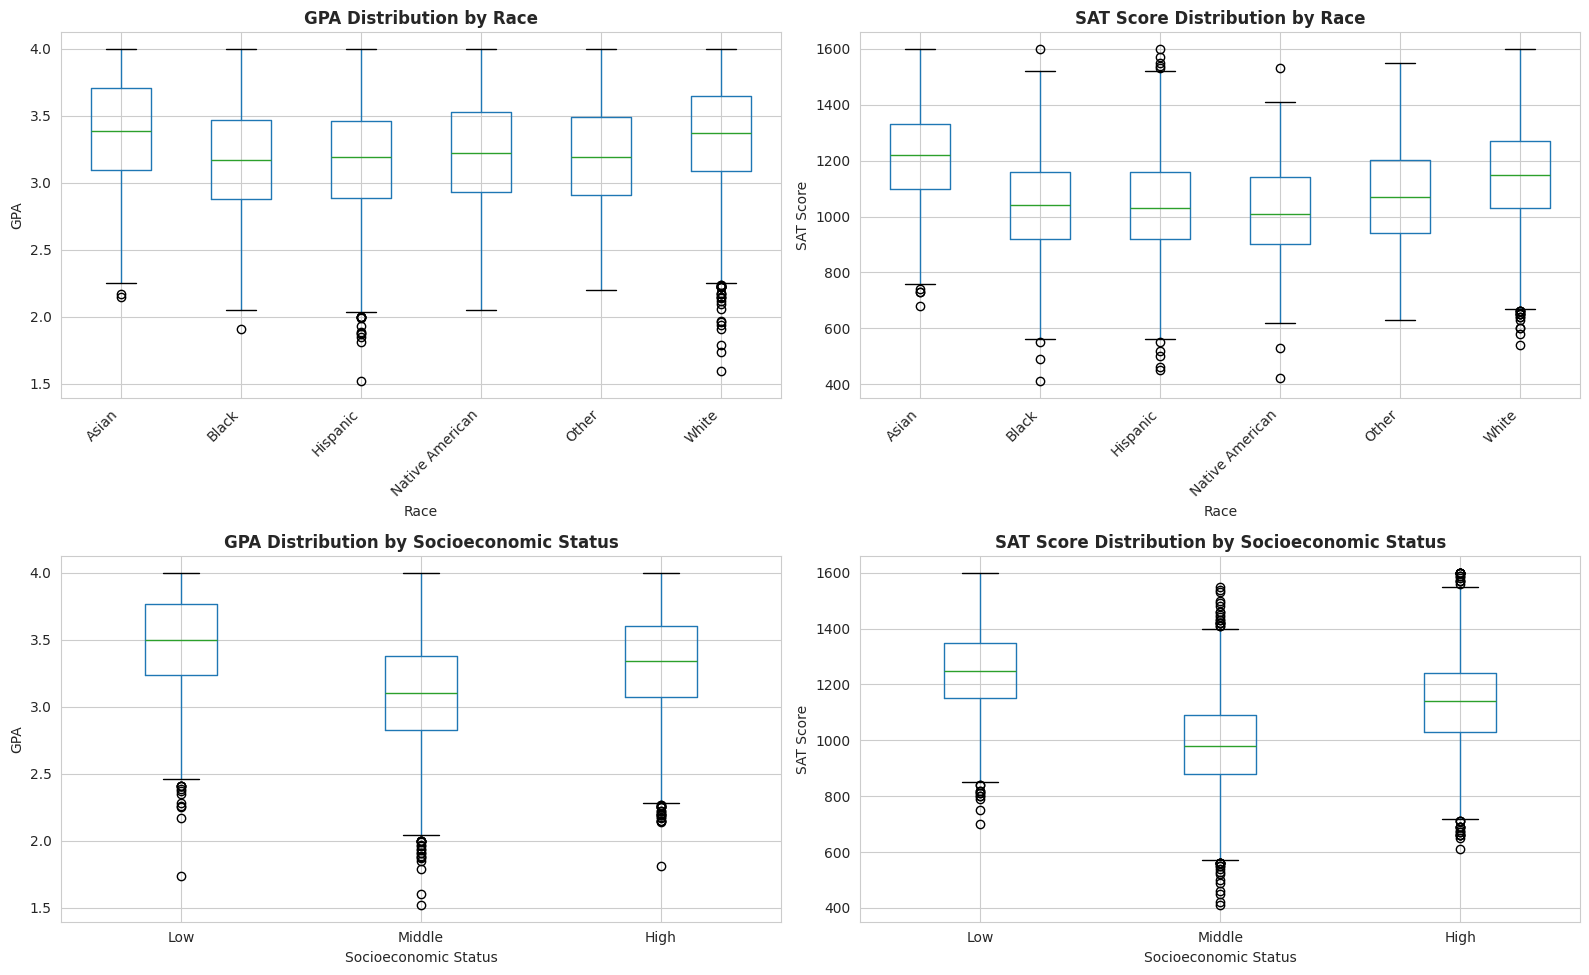

✓ Saved visualization as 'academic_metrics_by_demographics.png'


In [7]:
# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# GPA by Race
df.boxplot(column='gpa', by='race', ax=axes[0, 0])
axes[0, 0].set_title('GPA Distribution by Race', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Race')
axes[0, 0].set_ylabel('GPA')
plt.sca(axes[0, 0])
plt.xticks(rotation=45, ha='right')

# SAT by Race
df.boxplot(column='sat_score', by='race', ax=axes[0, 1])
axes[0, 1].set_title('SAT Score Distribution by Race', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Race')
axes[0, 1].set_ylabel('SAT Score')
plt.sca(axes[0, 1])
plt.xticks(rotation=45, ha='right')

# GPA by SES
ses_order = ['Low', 'Middle', 'High']
df.boxplot(column='gpa', by='socioeconomic_status', ax=axes[1, 0], positions=[0, 1, 2])
axes[1, 0].set_title('GPA Distribution by Socioeconomic Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Socioeconomic Status')
axes[1, 0].set_ylabel('GPA')
axes[1, 0].set_xticklabels(ses_order)

# SAT by SES
df.boxplot(column='sat_score', by='socioeconomic_status', ax=axes[1, 1], positions=[0, 1, 2])
axes[1, 1].set_title('SAT Score Distribution by Socioeconomic Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Socioeconomic Status')
axes[1, 1].set_ylabel('SAT Score')
axes[1, 1].set_xticklabels(ses_order)

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

## 6. Summary of Built-in Biases

The dataset intentionally includes realistic systemic biases:

1. **Socioeconomic Disparities**:
   - Higher SES students have better SAT scores (test prep access)
   - More AP courses at wealthy schools
   - Stronger recommendations through better networks

2. **Racial Disparities**:
   - Correlation between race and SES (historical inequalities)
   - Test score gaps across racial groups
   - Admission bias favoring White and Asian applicants

3. **Geographic & Other Biases**:
   - Rural students have fewer resources
   - First-generation students face disadvantages
   - Subtle gender bias in admission decisions

These biases allow us to test fairness metrics and evaluate whether ML models amplify or mitigate them.

## Next Steps

1. Run AIDE-ML baseline model for admission prediction
2. Evaluate fairness metrics (demographic parity, equalized odds, etc.)
3. Test fairness-aware AIDE prompts
4. Implement and compare alternative fairness approaches
5. Create custom fair model from scratch
6. Generate comprehensive comparison report